In [22]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [26]:
# link of the dataset
# https://huggingface.co/datasets/arbml/ashaar/tree/main/data
df = pd.read_parquet('../datasets/train-00000-of-00002.parquet')

In [3]:
# to remove rows with empty meter
dff = df[df["poem meter"].notna()]

# to remove rows with empty verses
dfff = dff[dff["poem verses"].notna()]

In [4]:
# view of number of each baher in the dataset
dfff["poem meter"].value_counts()

poem meter
بحر الطويل      14756
الطويل          12758
الكامل           9998
بحر الكامل       8854
بحر البسيط       8306
                ...  
الهجيني             1
الحداء              1
الصخري              1
مجزوء الخفيف        1
عدة أبحر            1
Name: count, Length: 99, dtype: int64

In [ ]:
# view of one verse from the dataset
' '.join(dfff["poem verses"][0].tolist())

'أَصبَحَ المُلك لِلَّذي فَطر الخَل قَ بِتَقديرٍ للعَزيز العَليمِ غافر الذَنب للمسيءِ بِعَفوٍ قابل التَوب ذي العَطاء العَميمِ مُرسل المُصطَفى البَشير إِلَينا رَحمة مِنهُ بِالكَلام القَديمِ رَبَنا رَبّنا إِلَيكَ أَنينا فَأَجرنا مِن حَر نار الجَحيمِ وَاكفِنا شَرّ ما نَخاف بِلُطفٍ يا عَظيماً يَرجى لِكُل عَظيمِ وَتَقبل أَعمالَنا وَاعفُ عَنا وَأَنلنا دُخول دار النَعيمِ بِنَبي بَعثَتهُ فَهَدانا لِصِراط مِن الهُدى مُستَقيمِ وَبِمَن نَحنُ في حِماهُ مَدى الدَهر أَخيهِ يَحيى الحصور الكَريمِ أَدرك أَدرك قَوماً أَتوا بافتقار وَاِنكِسار وَمَدمَع مَسجومِ شَهدت أَرواحَهُم أَنكَ اللَهُ وَجاءوا بِكُل قَلبٍ سَليم'

In [5]:
# to keep only bahers that have more than 3000 samples
data = dfff
dfs = pd.DataFrame(data)
column_name = 'poem meter'
min_count = 3000
counts = dfs[column_name].value_counts()
frequent_values = counts[counts > min_count].index
filtered_df = dfs[dfs[column_name].isin(frequent_values)]

In [7]:
# number of bahers on filtered dataset
filtered_df["poem meter"].nunique()

12

In [8]:
# to get only 3000 samples of each baher and remove the rest
df_sampled = filtered_df.groupby('poem meter').head(3000)

In [11]:
# to remove tshkeel from verses
verses = []
for x in df_sampled["poem verses"]:
    text = re.sub(r'[\u064B-\u065F]', '', str(' '.join(x.tolist())))
    verses.append(text)

In [14]:
# to convert verses to their vectory representation
vectorizer = TfidfVectorizer(ngram_range=(1,1),max_features=50000)
X = vectorizer.fit_transform(verses)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, df_sampled["poem meter"], test_size=0.2, random_state=42)

In [19]:
# train on naive bayes classifier after scaling the vectors
clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MaxAbsScaler()), ('clf', MultinomialNB())])

In [20]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 93.66%
Test Accuracy: 65.03%


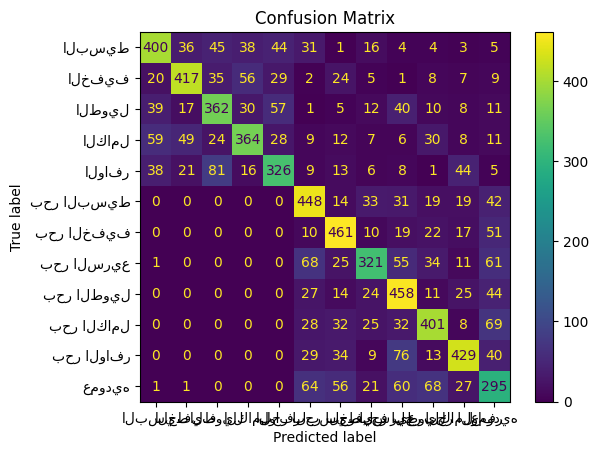

In [25]:
# to view confusion matrix
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()